Goal of this notebook:

1. Show the evaluation for a single cell or branch

2. Evaluate and visualize different parameters across cells (full pipeline)

In [1]:
import bulb_detection as bd
import skeliner as sk
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import median_filter

Load seg and annotations

In [2]:
seg_id = '720575940557301732'
skel = bd.load_skeleton('../recalibrated skeletons/' + seg_id + '_skel_recal_75.0.pkl')
ann = bd.parse_annotations_json('../revised_annotations/revised_ann_' + seg_id + '.json')

In [3]:
voxelsize = bd.io.get_layer_voxelsize(ann=ann, layer_id=3)
annotated_bulb_starts, annotated_bulb_ends = bd.io.get_annotated_bulb_coords(ann=ann, layer_id=3, voxelsize=voxelsize)

In [4]:
# Filter the annotations to include only the revised annotatiosn (on the path to annotated endpoint nodes)
endpoint_coords = bd.io.get_endpoint_coords(ann=ann, layer_id=4, voxelsize=voxelsize)
endpoint_nodes = []
for endpoint_coord in endpoint_coords:
    endpoint_node, _ = bd.graph.coords_to_nodes(skel=skel, query_coords=endpoint_coord)
    endpoint_nodes.append(endpoint_node)
endpoint_nodes = np.array(endpoint_nodes)

bulb_starts_on_path, bulb_ends_on_path = bd.graph.filter_bulb_coords_by_endpoints(
    skel=skel,
    starts_coords=annotated_bulb_starts,
    ends_coords=annotated_bulb_ends,
    endpoint_nodes=endpoint_nodes
)

In [5]:
skel = bd.graph.prune_skeleton_from_node_ids(skel=skel, keep_node_ids=endpoint_nodes)

In [6]:
gt_start_nodes, _ = bd.graph.coords_to_nodes(skel, bulb_starts_on_path)
gt_end_nodes, _ = bd.graph.coords_to_nodes(skel, bulb_ends_on_path)
gt_clusters = bd.graph.get_bulb_clusters(skel, gt_start_nodes, gt_end_nodes)

In [7]:
geodesic_dists = bd.graph.compute_geodesic_distances(skel)
radii = skel.radii['calibrated']

In [8]:
predicted_bulb_clusters, predicted_bulb_coords, branch_thresholds = bd.signal.predict_bulbs(
    skel=skel,
    geodesic_dists=geodesic_dists,
    radii=radii,
    window_size=15.0,
    k=2.0
)

Match the predicted and ground thruth clusters

In [9]:
tp_clusters, fp_clusters, fn_clusters = bd.evaluate.match_clusters(
    gt_clusters=gt_clusters,
    pred_clusters=predicted_bulb_clusters,
    iou_threshold=0.5
)

print(f'True positives: {len(tp_clusters)}')
print(f'False positives: {len(fp_clusters)}')
print(f'False negatives: {len(fn_clusters)}')

True positives: 104
False positives: 41
False negatives: 11


In [10]:
results = bd.evaluate.evaluate_detection(
    gt_clusters=gt_clusters,
    pred_clusters=predicted_bulb_clusters,
    iou_threshold=0.5
)

print(f'Precision: {results['precision']:.3f}')
print(f'Recall: {results['recall']:.3f}')
print(f'F1 score: {results['f1_score']:.3f}')

Precision: 0.717
Recall: 0.904
F1 score: 0.800


Merge clusters

In [11]:
merged_bulb_clusters = bd.signal.merge_split_clusters(
    skel=skel,
    geodesic_dists=geodesic_dists,
    clusters=predicted_bulb_clusters,
    merge_threshold_um=1.0
)

merged_results = bd.evaluate.evaluate_detection(
    gt_clusters=gt_clusters,
    pred_clusters=merged_bulb_clusters,
    iou_threshold=0.5
)

print('Before merging:')
print(f'Precision: {results['precision']:.3f}')
print(f'Recall: {results['recall']:.3f}')
print(f'F1 score: {results['f1_score']:.3f}')

print('\nAfter merging:')
print(f'Precision: {merged_results['precision']:.3f}')
print(f'Recall: {merged_results['recall']:.3f}')
print(f'F1 score: {merged_results['f1_score']:.3f}')

Before merging:
Precision: 0.717
Recall: 0.904
F1 score: 0.800

After merging:
Precision: 0.752
Recall: 0.896
F1 score: 0.817


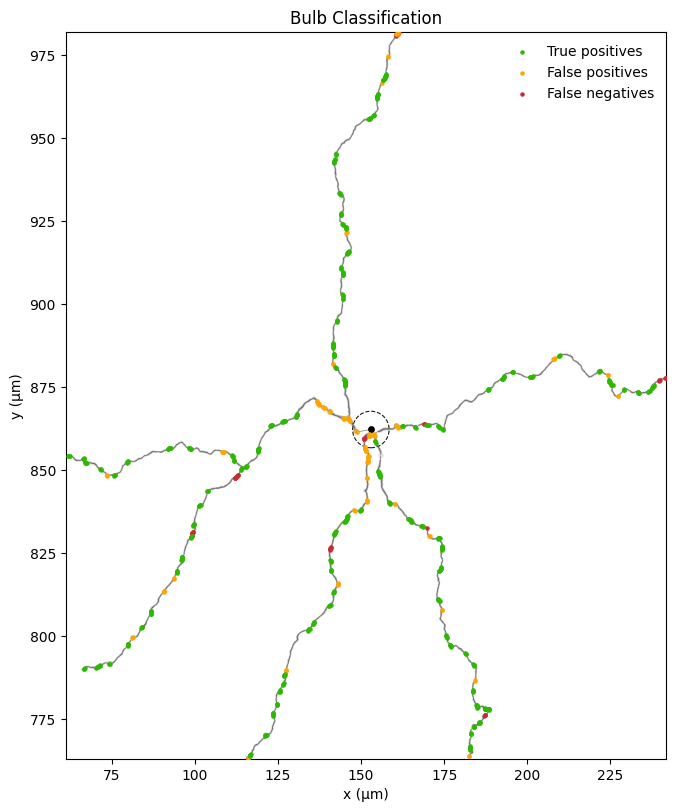

In [12]:
ax = bd.visualization.plot_evaluation_on_skeleton(
    skel=skel,
    tp_nodes=np.concatenate(tp_clusters),
    fp_nodes=np.concatenate(fp_clusters),
    fn_nodes=np.concatenate(fn_clusters),
    s=5
)